# День 9: Очистка данных

**Цель дня:** научиться находить и исправлять «грязные» данные — дубликаты, пропуски, выбросы, неверные типы.

**Итог дня:** пройдёшь полный пайплайн очистки каротажного датасета и получишь чистый DataFrame.

---

## Что изучаем сегодня:

| Тема | Зачем геологу |
|------|--------------|
| **Аудит данных** | Понять масштаб проблем до начала работы |
| **Дубликаты** | При сборке из разных файлов строки дублируются |
| **Пропуски (NaN)** | -999.25 в LAS, сбои прибора |
| **Неверные типы** | Глубина как строка, коды как float |
| **Выбросы** | Пики на ГК — реальные или артефакты? |
| **Итоговый пайплайн** | Одна функция `clean_welldata()` для любой скважины |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

print("Pandas:", pd.__version__)
print("NumPy: ", np.__version__)
print("Готово!")

Pandas: 2.3.3
NumPy:  2.3.4
Готово!


---
## Часть 1: Создаём «грязный» датасет для практики

Возьмём A15 и добавим типичные «загрязнения»:
- **дублированные строки** — как при объединении файлов из двух источников
- **строка вместо числа** — одна запись с DEPTH = `"1850.5"` (текст)
- **дополнительные пропуски** — 5% ячеек GR обнулились
- **выбросы-артефакты** — GR = 850 (прибор дал пик)

In [2]:
# Загружаем чистый файл A15
df_raw = pd.read_csv("A15", skiprows=32, sep=r"\s+", header=None,
                     names=["DEPTH", "GR", "Perm", "Porosity", "Resistivity", "LITH"])
df_raw = df_raw.replace(-999.25, np.nan)

print(f"Загружено строк: {len(df_raw)}")
df_raw.head()

Загружено строк: 552


,DEPTH,GR,Perm,Porosity,Resistivity,LITH
0,1808.8947,NaN,NaN,NaN,NaN,NaN
1,1809.3947,84.426910,0.000819,0.001897,0.652335,2.0
2,1809.8947,72.081619,0.001172,0.001951,1.256779,2.0
3,1810.3947,73.515076,0.001056,0.001919,1.058033,2.0
4,1810.8947,78.625954,0.000814,0.001899,0.644028,2.0


In [3]:
# Создаём «грязную» копию
np.random.seed(42)
df_dirty = df_raw.copy()

# 1. Дубликаты — 10 случайных строк
dup_idx = np.random.choice(df_dirty.index, size=10, replace=False)
df_dirty = pd.concat([df_dirty, df_dirty.loc[dup_idx]], ignore_index=True)

# 2. Неверный тип — строка вместо числа в DEPTH
bad_row = pd.DataFrame([["1850.5", 45.2, 0.12, 0.18, 12.5, 1]],
                        columns=df_dirty.columns)
df_dirty = pd.concat([df_dirty, bad_row], ignore_index=True)

# 3. Дополнительные NaN в GR
nan_idx = np.random.choice(df_dirty.index, size=28, replace=False)
df_dirty.loc[nan_idx, "GR"] = np.nan

# 4. Выбросы-артефакты
spike_idx = np.random.choice(df_dirty.index, size=5, replace=False)
df_dirty.loc[spike_idx, "GR"] = 850.0

# Перемешиваем (имитируем «сборный» файл)
df_dirty = df_dirty.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Грязный датасет: {df_dirty.shape[0]} строк × {df_dirty.shape[1]} столбцов")
df_dirty.head(10)

Грязный датасет: 563 строк × 6 столбцов


,DEPTH,GR,Perm,Porosity,Resistivity,LITH
0,1933.8947,65.647537,0.001613,0.001907,2.502374,2.0
1,2069.3947,120.002563,0.000179,0.000587,0.413285,0.0
2,1942.8947,63.548660,0.001879,0.001920,3.347661,2.0
3,1836.3947,76.795387,0.001610,0.001909,2.489413,2.0
4,2083.3947,NaN,NaN,NaN,NaN,NaN
5,1972.8947,75.528214,0.001203,0.001815,1.551339,2.0
6,1931.3947,NaN,0.001237,0.001923,1.446127,2.0
7,2068.8947,117.527771,0.000194,0.000533,0.595965,0.0
8,1849.8947,83.218712,0.001235,0.001900,1.479726,2.0
9,2073.3947,122.829872,0.000145,0.000480,0.423392,0.0


---
## Часть 2: Аудит данных — «медосмотр» датасета

Прежде чем чистить — нужно понять **масштаб проблем**.

```python
df.info()              # типы, количество непустых значений
df.describe()          # мин, макс, среднее, перцентили
df.isnull().sum()      # количество NaN по столбцам
df.duplicated().sum()  # количество дублированных строк
```

In [4]:
# Шаг 1: типы и пропуски
print("=" * 50)
print("df.info() — типы данных и пропуски:")
print("=" * 50)
df_dirty.info()

df.info() — типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPTH        563 non-null    object 
 1   GR           531 non-null    float64
 2   Perm         559 non-null    float64
 3   Porosity     558 non-null    float64
 4   Resistivity  558 non-null    float64
 5   LITH         558 non-null    float64
dtypes: float64(5), object(1)
memory usage: 26.5+ KB


In [5]:
# Шаг 2: статистика — ищем аномальные max/min
print("df.describe() — обрати внимание на max значения:")
df_dirty.describe()

df.describe() — обрати внимание на max значения:


,GR,Perm,Porosity,Resistivity,LITH
count,531.000000,559.000000,558.000000,558.000000,558.000000
mean,95.015392,0.001426,0.001874,3.143617,1.517921
std,78.240519,0.005169,0.007574,6.356227,0.794190
min,39.224728,0.000029,0.000228,0.002951,0.000000
25%,67.529587,0.000212,0.001284,0.267699,1.000000
50%,78.625954,0.000977,0.001845,1.022882,2.000000
75%,119.354023,0.001738,0.001924,2.983656,2.000000
max,850.000000,0.120000,0.180000,77.801315,3.000000


In [6]:
# Шаг 3: полный отчёт о качестве данных
print("ОТЧЁТ О КАЧЕСТВЕ ДАННЫХ")
print("=" * 40)
print(f"Всего строк:      {len(df_dirty)}")
print(f"Дубликатов:       {df_dirty.duplicated().sum()}")
print()
print("Пропуски по столбцам:")
nan_info = df_dirty.isnull().sum()
nan_pct  = (nan_info / len(df_dirty) * 100).round(1)
for col in df_dirty.columns:
    bar = "█" * int(nan_pct[col] / 2)
    print(f"  {col:<14} {nan_info[col]:>4} NaN  ({nan_pct[col]:>5.1f}%)  {bar}")
print()
print("Типы данных:")
for col, dtype in df_dirty.dtypes.items():
    note = " ← ПРОБЛЕМА: должен быть float!" if dtype == object else ""
    print(f"  {col:<14} {str(dtype):<10}{note}")

ОТЧЁТ О КАЧЕСТВЕ ДАННЫХ
Всего строк:      563
Дубликатов:       9

Пропуски по столбцам:
  DEPTH             0 NaN  (  0.0%)  
  GR               32 NaN  (  5.7%)  ██
  Perm              4 NaN  (  0.7%)  
  Porosity          5 NaN  (  0.9%)  
  Resistivity       5 NaN  (  0.9%)  
  LITH              5 NaN  (  0.9%)  

Типы данных:
  DEPTH          object     ← ПРОБЛЕМА: должен быть float!
  GR             float64   
  Perm           float64   
  Porosity       float64   
  Resistivity    float64   
  LITH           float64   


---
## Часть 3: Дубликаты

**Дубликат** — строка, которая полностью совпадает с другой строкой.

```python
df.duplicated()                  # True/False маска
df[df.duplicated()]              # показать дублированные строки
df.drop_duplicates()             # удалить, оставить первое вхождение
df.duplicated(subset=["DEPTH"])  # дубли только по одному столбцу
```

> `keep='first'` (по умолчанию) — оставить первое. `keep='last'` — последнее. `keep=False` — удалить все.

In [8]:
# Находим и смотрим на дубликаты
n_dups = df_dirty.duplicated().sum()
print(f"Полных дубликатов: {n_dups}")
print()
print("Пример — первые 6 строк (3 пары дублей):")
df_dirty[df_dirty.duplicated(keep=False)].head(6)

Полных дубликатов: 9

Пример — первые 6 строк (3 пары дублей):


,DEPTH,GR,Perm,Porosity,Resistivity,LITH
8,1849.8947,83.218712,0.001235,0.001900,1.479726,2.0
35,1849.3947,76.798065,0.001293,0.001882,1.657063,2.0
40,1848.3947,67.995300,0.001357,0.001968,1.651898,2.0
52,2056.3947,120.457573,0.000195,0.000560,0.541634,0.0
70,1944.8947,79.324120,0.001142,0.001815,1.399016,2.0
85,1878.8947,73.640297,0.001345,0.001975,1.611471,2.0


In [9]:
# Удаляем дубликаты
df_step1 = df_dirty.drop_duplicates().reset_index(drop=True)

print(f"До удаления:    {len(df_dirty)} строк")
print(f"После удаления: {len(df_step1)} строк")
print(f"Удалено:        {len(df_dirty) - len(df_step1)} строк")

До удаления:    563 строк
После удаления: 554 строк
Удалено:        9 строк


### Задание 1
Найди дубликаты **только по столбцу `DEPTH`** — бывает, что две разные строки
стоят на одной глубине (разные приборы, разные рейсы).

```python
df_step1.duplicated(subset=["DEPTH"]).sum()
```

In [ ]:
# Твой код здесь:


---
## Часть 4: Исправление типов данных

Из-за одной строки `"1850.5"` весь столбец `DEPTH` стал **object** (строка).
Pandas не может делать математику со строками!

```python
df["col"].astype(float)                       # принудительно — упадёт при ошибке
pd.to_numeric(df["col"], errors="coerce")      # безопасно — нечисловые → NaN
```

> `errors='coerce'` — «если не получается перевести, поставь NaN».  
> Это безопаснее чем `astype()`, который падает с ошибкой на первом же мусоре.

In [10]:
# Находим нечисловые значения в DEPTH
print("Тип DEPTH до исправления:", df_step1["DEPTH"].dtype)

mask_bad = pd.to_numeric(df_step1["DEPTH"], errors="coerce").isnull()
print(f"Нечисловых значений: {mask_bad.sum()}")
print()
print("Проблемные строки:")
print(df_step1[mask_bad])

Тип DEPTH до исправления: object
Нечисловых значений: 0

Проблемные строки:
Empty DataFrame
Columns: [DEPTH, GR, Perm, Porosity, Resistivity, LITH]
Index: []


In [11]:
# Конвертируем все столбцы корректно
df_step2 = df_step1.copy()

for col in ["DEPTH", "GR", "Perm", "Porosity", "Resistivity", "LITH"]:
    df_step2[col] = pd.to_numeric(df_step2[col], errors="coerce")

df_step2["LITH"] = df_step2["LITH"].astype("Int64")

print("Типы после исправления:")
print(df_step2.dtypes)
print()
print(f"Новых NaN в DEPTH (от конвертации): {df_step2['DEPTH'].isnull().sum()}")

Типы после исправления:
DEPTH          float64
GR             float64
Perm           float64
Porosity       float64
Resistivity    float64
LITH             Int64
dtype: object

Новых NaN в DEPTH (от конвертации): 0


---
## Часть 5: Стратегии работы с пропусками (NaN)

Нет одного правильного ответа — стратегия зависит от **контекста**:

| Стратегия | Метод | Когда применять |
|-----------|-------|-----------------|
| Удалить строки | `dropna()` | NaN мало, строк достаточно |
| Заполнить средним | `fillna(mean)` | Случайные пропуски, нет выбросов |
| Заполнить медианой | `fillna(median)` | Есть выбросы |
| Протащить | `ffill()` | **Каротаж**: литология меняется плавно |
| Интерполяция | `interpolate()` | **Каротаж**: непрерывные кривые |

В каротажных данных **`interpolate()` и `ffill()`** — лучший выбор:  
свойства пород меняются плавно по глубине, а не скачками.

In [12]:
# Смотрим на пропуски после исправления типов
print("Пропуски в каждом столбце:")
nan_counts = df_step2.isnull().sum()
for col, cnt in nan_counts.items():
    pct = cnt / len(df_step2) * 100
    print(f"  {col:<14} {cnt:>4} NaN ({pct:.1f}%)")

Пропуски в каждом столбце:
  DEPTH             0 NaN (0.0%)
  GR               32 NaN (5.8%)
  Perm              4 NaN (0.7%)
  Porosity          5 NaN (0.9%)
  Resistivity       5 NaN (0.9%)
  LITH              5 NaN (0.9%)


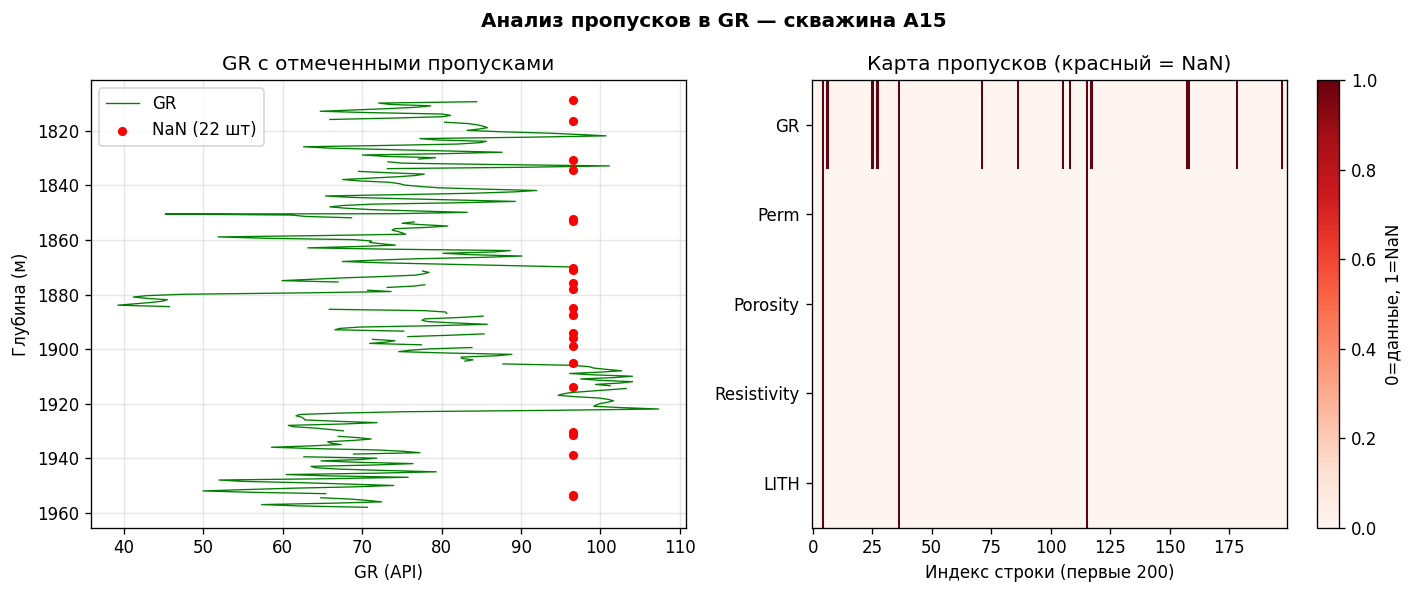

In [13]:
# Визуализируем где пропуски в GR (случайные или блоками?)
df_sorted = df_step2.dropna(subset=["DEPTH"]).sort_values("DEPTH").head(300).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Анализ пропусков в GR — скважина A15", fontweight="bold")

# GR по глубине с отмеченными NaN
axes[0].plot(df_sorted["GR"], df_sorted["DEPTH"],
             color="green", linewidth=0.8, label="GR")
nan_mask = df_sorted["GR"].isnull()
axes[0].scatter(
    [df_sorted["GR"].max() * 0.9] * nan_mask.sum(),
    df_sorted["DEPTH"][nan_mask],
    color="red", s=20, zorder=5, label=f"NaN ({nan_mask.sum()} шт)")
axes[0].invert_yaxis()
axes[0].set_xlabel("GR (API)")
axes[0].set_ylabel("Глубина (м)")
axes[0].set_title("GR с отмеченными пропусками")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Тепловая карта пропусков
cols_check = ["GR", "Perm", "Porosity", "Resistivity", "LITH"]
null_matrix = df_step2[cols_check].isnull().astype(int).head(200)
axes[1].imshow(null_matrix.T, aspect="auto", cmap="Reds", interpolation="nearest")
axes[1].set_yticks(range(len(cols_check)))
axes[1].set_yticklabels(cols_check)
axes[1].set_xlabel("Индекс строки (первые 200)")
axes[1].set_title("Карта пропусков (красный = NaN)")
plt.colorbar(axes[1].images[0], ax=axes[1], label="0=данные, 1=NaN")

plt.tight_layout()
plt.show()

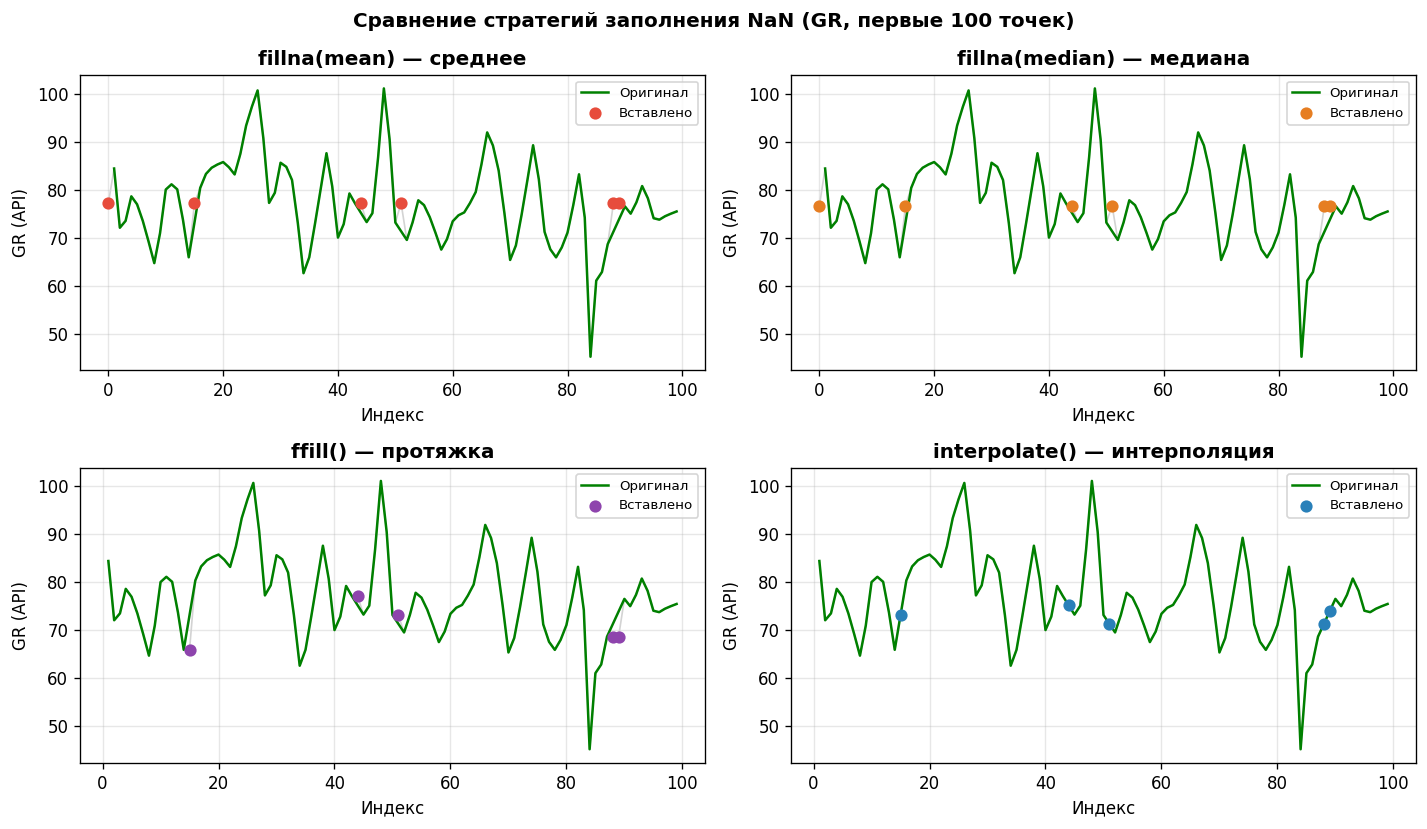

Вывод: для каротажа interpolate() сохраняет форму кривой.
fillna(mean) создаёт нереалистичные горизонтальные скачки!


In [14]:
# Сравниваем стратегии визуально
sample = df_step2.sort_values("DEPTH").reset_index(drop=True).head(100)
gr = sample["GR"]

strategies = {
    "fillna(mean) — среднее":       gr.fillna(gr.mean()),
    "fillna(median) — медиана":     gr.fillna(gr.median()),
    "ffill() — протяжка":           gr.ffill(),
    "interpolate() — интерполяция": gr.interpolate(method="linear"),
}

colors = ["#e74c3c", "#e67e22", "#8e44ad", "#2980b9"]
nan_pos = gr[gr.isnull()].index

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Сравнение стратегий заполнения NaN (GR, первые 100 точек)",
             fontweight="bold")

for ax, (title, filled), color in zip(axes.flat, strategies.items(), colors):
    ax.plot(filled.index, filled.values, color="lightgray", linewidth=1)
    ax.plot(gr.dropna().index, gr.dropna().values, color="green", linewidth=1.5, label="Оригинал")
    ax.scatter(nan_pos, filled[nan_pos], color=color, s=40, zorder=5, label="Вставлено")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Индекс")
    ax.set_ylabel("GR (API)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Вывод: для каротажа interpolate() сохраняет форму кривой.")
print("fillna(mean) создаёт нереалистичные горизонтальные скачки!")

In [15]:
# Применяем оптимальную стратегию для каротажных данных
df_step3 = df_step2.dropna(subset=["DEPTH"]).sort_values("DEPTH").reset_index(drop=True).copy()

# GR, Porosity, Resistivity — линейная интерполяция
for col in ["GR", "Porosity", "Resistivity"]:
    df_step3[col] = df_step3[col].interpolate(method="linear")

# Perm — логарифмическая (логнормальное распределение)
log_p = np.log10(df_step3["Perm"].replace(0, np.nan))
df_step3["Perm"] = 10 ** log_p.interpolate(method="linear")

# LITH — протяжка (литология не меняется резко)
df_step3["LITH"] = df_step3["LITH"].ffill().bfill()

print("NaN после заполнения:")
print(df_step3.isnull().sum())
print(f"\nОсталось строк: {len(df_step3)}")

NaN после заполнения:
DEPTH          0
GR             1
Perm           1
Porosity       1
Resistivity    1
LITH           0
dtype: int64

Осталось строк: 554


### Задание 2
Проверь: если бы мы использовали `fillna(mean)` для GR вместо `interpolate()`,
как изменилась бы **медиана** GR?

```python
gr_mean_fill  = df_step2["GR"].fillna(df_step2["GR"].mean())
gr_interp     = df_step2["GR"].interpolate()
print(gr_mean_fill.median(), gr_interp.median())
```

Что будет больше? Почему так происходит?

In [ ]:
# Твой код здесь:


---
## Часть 6: Обнаружение и обработка выбросов

**Выброс** — значение, сильно отличающееся от остальных. В каротаже:
- **Артефакт прибора** → нужно удалить
- **Реальная геология** (уголь, рудное тело) → нужно сохранить!

### Метод Z-score (правило 3σ)
```
z = (x − μ) / σ       выброс если |z| > 3
```

### Метод IQR (межквартильный размах)
```
IQR = Q3 − Q1
выброс если x < Q1 − 1.5·IQR  или  x > Q3 + 1.5·IQR
```

> **Z-score** чувствителен к самим выбросам (смещают среднее).  
> **IQR** устойчив — медиана не смещается от пика.

In [16]:
# Функции обнаружения выбросов
def zscore_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

def iqr_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)

# Применяем к GR
mask_z   = zscore_outliers(df_step3["GR"])
mask_iqr = iqr_outliers(df_step3["GR"])

print(f"Выбросов по Z-score (|z|>3):  {mask_z.sum()}")
print(f"Выбросов по IQR (1.5×IQR):    {mask_iqr.sum()}")
print()
print("Значения выбросов (Z-score):")
print(df_step3[mask_z][["DEPTH", "GR"]].to_string())

Выбросов по Z-score (|z|>3):  5
Выбросов по IQR (1.5×IQR):    5

Значения выбросов (Z-score):
         DEPTH     GR
304  1960.3947  850.0
316  1966.3947  850.0
377  1996.8947  850.0
453  2034.8947  850.0
533  2074.3947  850.0


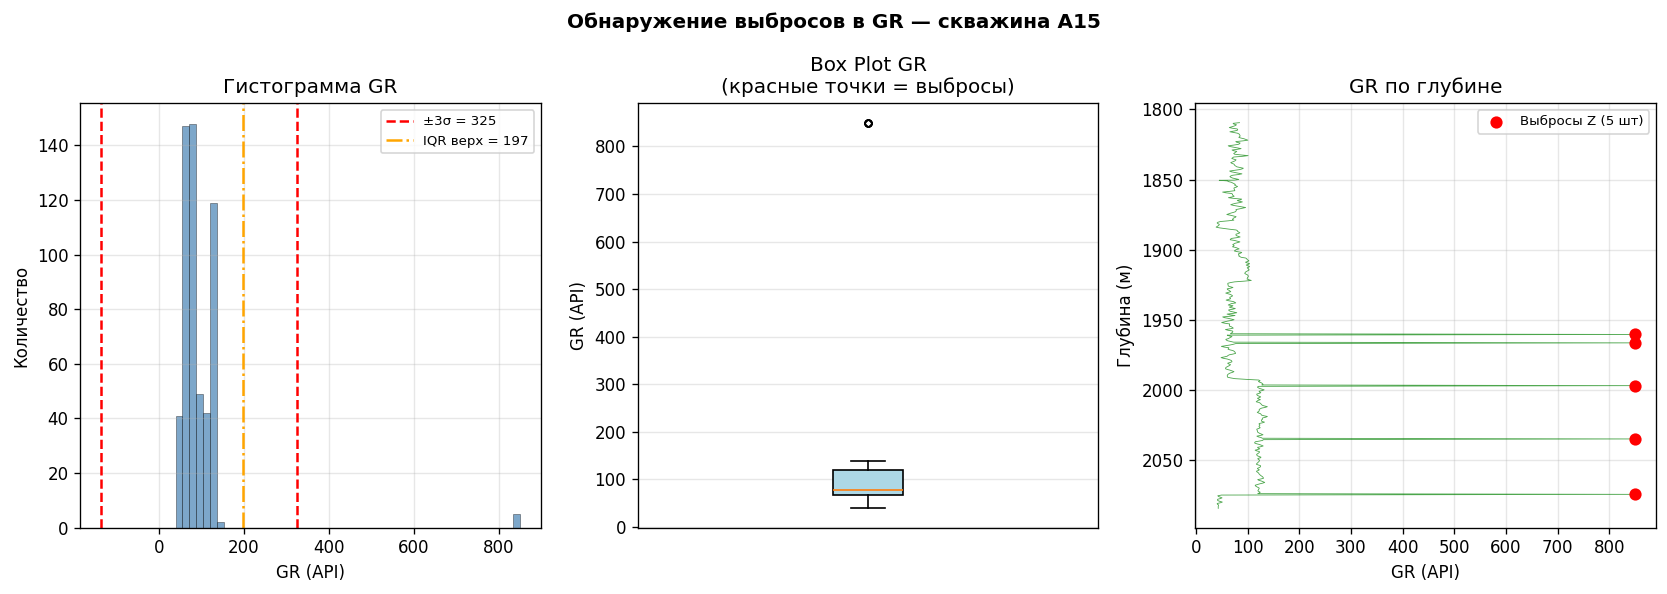

In [17]:
# Визуализация выбросов
gr = df_step3["GR"]
mean_gr, std_gr = gr.mean(), gr.std()
Q1, Q3 = gr.quantile(0.25), gr.quantile(0.75)
IQR = Q3 - Q1

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Обнаружение выбросов в GR — скважина A15", fontweight="bold")

# 1. Гистограмма с границами выбросов
axes[0].hist(gr, bins=50, color="steelblue", alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].axvline(mean_gr + 3*std_gr, color="red",    linestyle="--", label=f"±3σ = {mean_gr+3*std_gr:.0f}")
axes[0].axvline(mean_gr - 3*std_gr, color="red",    linestyle="--")
axes[0].axvline(Q3 + 1.5*IQR,       color="orange", linestyle="-.", label=f"IQR верх = {Q3+1.5*IQR:.0f}")
axes[0].set_xlabel("GR (API)")
axes[0].set_ylabel("Количество")
axes[0].set_title("Гистограмма GR")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Box plot
axes[1].boxplot(gr.dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               flierprops=dict(marker="o", color="red", markersize=4))
axes[1].set_ylabel("GR (API)")
axes[1].set_title("Box Plot GR\n(красные точки = выбросы)")
axes[1].set_xticks([])
axes[1].grid(True, alpha=0.3)

# 3. GR по глубине с выбросами
axes[2].plot(gr, df_step3["DEPTH"], color="green", linewidth=0.5, alpha=0.7)
axes[2].scatter(gr[mask_z], df_step3["DEPTH"][mask_z],
               color="red", s=40, zorder=5, label=f"Выбросы Z ({mask_z.sum()} шт)")
axes[2].invert_yaxis()
axes[2].set_xlabel("GR (API)")
axes[2].set_ylabel("Глубина (м)")
axes[2].set_title("GR по глубине")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Три стратегии обработки выбросов
upper = mean_gr + 3*std_gr
lower = mean_gr - 3*std_gr

gr_removed  = gr[~mask_z]                                 # удалить строки
gr_capped   = gr.clip(lower=lower, upper=upper)            # обрезать (Winsorization)
gr_interp   = gr.copy()
gr_interp[mask_z] = np.nan
gr_interp   = gr_interp.interpolate(method="linear")       # NaN → интерполяция

print(f"{'Метод':<22} {'Среднее':>10} {'Макс':>10} {'Строк':>8}")
print("-" * 52)
print(f"{'Оригинал':<22} {gr.mean():>10.1f} {gr.max():>10.1f} {len(gr):>8}")
print(f"{'Удаление строк':<22} {gr_removed.mean():>10.1f} {gr_removed.max():>10.1f} {len(gr_removed):>8}")
print(f"{'Clip (±3σ)':<22} {gr_capped.mean():>10.1f} {gr_capped.max():>10.1f} {len(gr_capped):>8}")
print(f"{'NaN + interpolate':<22} {gr_interp.mean():>10.1f} {gr_interp.max():>10.1f} {len(gr_interp):>8}")

Метод                     Среднее       Макс    Строк
----------------------------------------------------
Оригинал                     94.3      850.0      554
Удаление строк               87.4      138.5      549
Clip (±3σ)                   89.6      324.9      554
NaN + interpolate            87.5      138.5      554


In [ ]:
# Применяем обработку выбросов ко всем кривым
df_step4 = df_step3.copy()

for col in ["GR", "Porosity", "Resistivity"]:
    mask = zscore_outliers(df_step4[col])
    if mask.sum() > 0:
        df_step4.loc[mask, col] = np.nan
        df_step4[col] = df_step4[col].interpolate(method="linear")
        print(f"{col:<14}: обработано {mask.sum()} выбросов → интерполяция")
    else:
        print(f"{col:<14}: выбросов нет")

# Perm — IQR на лог. шкале (логнормальные данные)
mask_p = iqr_outliers(np.log10(df_step4["Perm"].replace(0, np.nan)))
df_step4.loc[mask_p, "Perm"] = np.nan
df_step4["Perm"] = df_step4["Perm"].interpolate()
print(f"{'Perm':<14}: обработано {mask_p.sum()} выбросов (IQR на лог. шкале)")

### Задание 3
Проверь выбросы в **Resistivity** методом IQR с `factor=2.0` (более строгий порог).

```python
mask_res = iqr_outliers(df_step4["Resistivity"], factor=2.0)
print(f"Выбросов: {mask_res.sum()}")
df_step4[mask_res][["DEPTH", "GR", "Resistivity"]]
```

Посмотри на глубины — высокое сопротивление может означать  
карбонат или коллектор с нефтью. Стоит ли их удалять?

In [ ]:
# Твой код здесь:


---
## Часть 7: Итоговый пайплайн очистки

Хороший пайплайн — одна функция, применимая к **любой скважине**:

```
1. Замена null LAS (-999.25 → NaN)
2. Конвертация типов (pd.to_numeric)
3. Удаление дубликатов
4. Сортировка по глубине
5. Интерполяция NaN
6. Обработка выбросов (Z-score)
7. Финальная проверка
```

In [19]:
def clean_welldata(df, null_value=-999.25, zscore_thresh=3):
    """Пайплайн очистки каротажного датасета."""
    report = {}
    df_clean = df.copy()

    # 1. Замена null LAS
    df_clean = df_clean.replace(null_value, np.nan)
    report["start_rows"] = len(df_clean)

    # 2. Конвертация типов
    for col in df_clean.columns:
        if col not in ["LITH_name", "Kategoria", "Zone"]:
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # 3. Дубликаты
    n_before = len(df_clean)
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    report["duplicates_removed"] = n_before - len(df_clean)

    # 4. Сортировка, удаление строк без глубины
    df_clean = df_clean.dropna(subset=["DEPTH"]).sort_values("DEPTH").reset_index(drop=True)

    # 5. Заполнение NaN
    for col in ["GR", "Porosity", "Resistivity", "Perm"]:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].interpolate(method="linear")
    if "LITH" in df_clean.columns:
        df_clean["LITH"] = df_clean["LITH"].ffill().bfill()
    report["nan_remaining"] = df_clean.isnull().sum().sum()

    # 6. Выбросы (Z-score)
    n_outliers = 0
    for col in ["GR", "Porosity", "Resistivity"]:
        if col in df_clean.columns:
            z = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
            mask = z.abs() > zscore_thresh
            n_outliers += mask.sum()
            df_clean.loc[mask, col] = np.nan
            df_clean[col] = df_clean[col].interpolate(method="linear")
    report["outliers_processed"] = n_outliers
    report["end_rows"] = len(df_clean)

    return df_clean, report

In [20]:
# Запускаем на грязном датасете
df_final, report = clean_welldata(df_dirty)

print("ОТЧЁТ О ПАЙПЛАЙНЕ ОЧИСТКИ")
print("=" * 35)
print(f"Исходно строк:           {report['start_rows']}")
print(f"Удалено дубликатов:      {report['duplicates_removed']}")
print(f"Обработано выбросов:     {report['outliers_processed']}")
print(f"Остаток NaN:             {report['nan_remaining']}")
print(f"Итого строк:             {report['end_rows']}")

ОТЧЁТ О ПАЙПЛАЙНЕ ОЧИСТКИ
Исходно строк:           563
Удалено дубликатов:      9
Обработано выбросов:     15
Остаток NaN:             4
Итого строк:             554


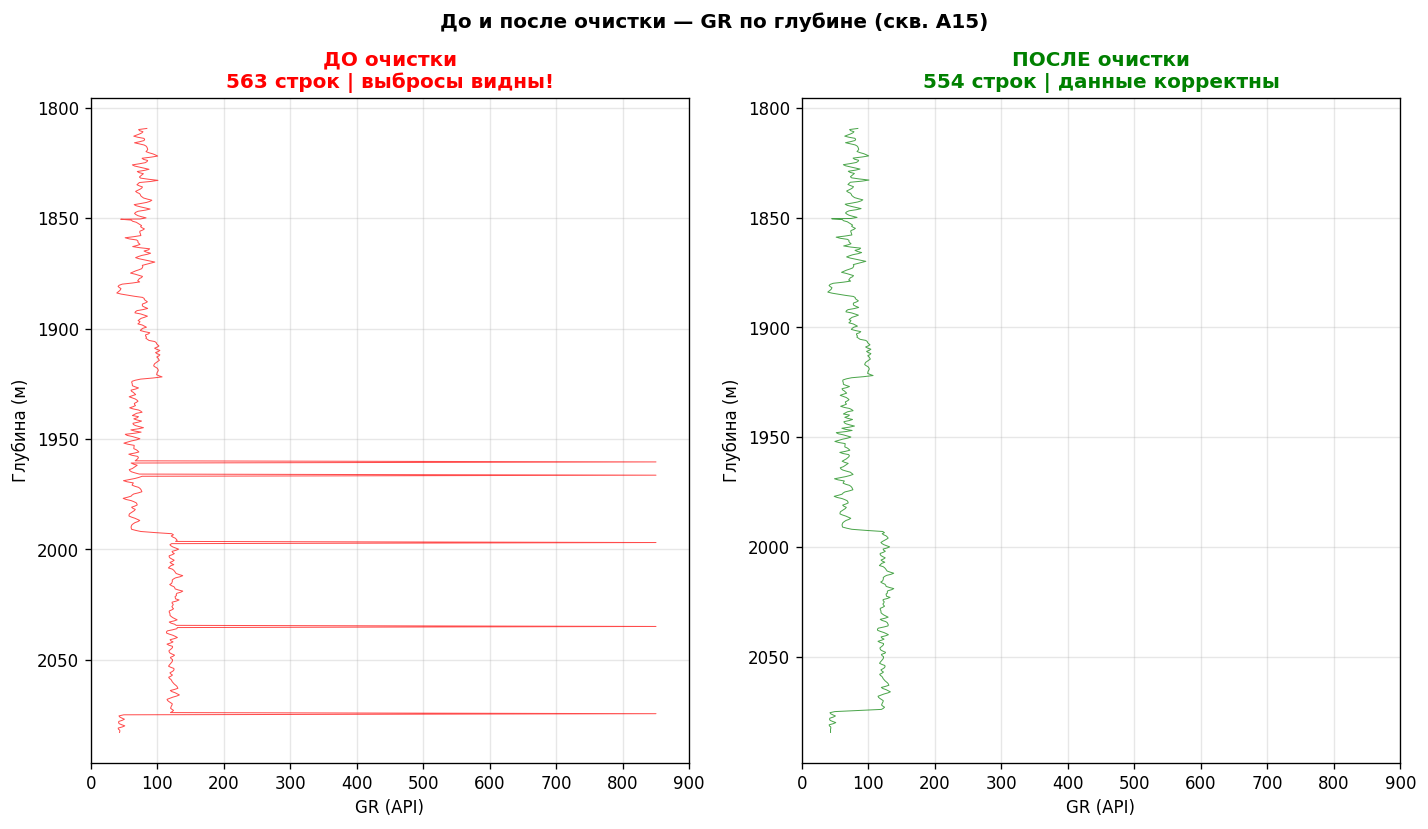

In [21]:
# До и после — сравнение GR по глубине
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle("До и после очистки — GR по глубине (скв. A15)",
             fontweight="bold", fontsize=12)

df_d = df_dirty.copy()
df_d["DEPTH"] = pd.to_numeric(df_d["DEPTH"], errors="coerce")
df_d["GR"]    = pd.to_numeric(df_d["GR"],    errors="coerce")
df_d = df_d.dropna(subset=["DEPTH", "GR"]).sort_values("DEPTH")

axes[0].plot(df_d["GR"], df_d["DEPTH"], color="red", linewidth=0.6, alpha=0.7)
axes[0].invert_yaxis()
axes[0].set_xlabel("GR (API)")
axes[0].set_ylabel("Глубина (м)")
axes[0].set_title(f"ДО очистки\n{len(df_dirty)} строк | выбросы видны!",
                  color="red", fontweight="bold")
axes[0].set_xlim(0, 900)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_final["GR"], df_final["DEPTH"], color="green", linewidth=0.6, alpha=0.7)
axes[1].invert_yaxis()
axes[1].set_xlabel("GR (API)")
axes[1].set_ylabel("Глубина (м)")
axes[1].set_title(f"ПОСЛЕ очистки\n{len(df_final)} строк | данные корректны",
                  color="green", fontweight="bold")
axes[1].set_xlim(0, 900)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Итоговое задание — Полная очистка скважины

Ты ведущий петрофизик. Тебе прислали «грязный» файл. Три шага:

1. Создай свой «грязный» датасет из `df_raw` — добавь **20 дубликатов** и **10 выбросов** (GR = 999)
2. Примени `clean_welldata()` к своему датасету
3. Сравни `max(GR)`, `len()` и количество NaN до и после

In [ ]:
# Шаг 1 — создаём грязный датасет


# Шаг 2 — применяем пайплайн


# Шаг 3 — сравниваем


---
## Шпаргалка Дня 9

```python
import pandas as pd
import numpy as np

# === АУДИТ ===
df.info()                          # типы и количество не-NaN
df.describe()                      # статистика
df.isnull().sum()                  # NaN по столбцам
df.duplicated().sum()              # дубликаты

# === ДУБЛИКАТЫ ===
df.drop_duplicates()               # удалить
df.duplicated(subset=["col"])      # дубли по одному столбцу

# === ТИПЫ ===
pd.to_numeric(df["col"], errors="coerce")   # безопасная конвертация
df["col"].astype("Int64")                   # nullable integer

# === ПРОПУСКИ ===
df["col"].fillna(df["col"].mean())    # заполнить средним
df["col"].ffill()                     # протяжка вниз
df["col"].interpolate()               # линейная интерполяция
df.dropna(subset=["col"])             # удалить строки с NaN в col

# === ВЫБРОСЫ ===
# Z-score:
z = (df["col"] - df["col"].mean()) / df["col"].std()
mask = z.abs() > 3

# IQR:
Q1, Q3 = df["col"].quantile([0.25, 0.75])
IQR = Q3 - Q1
mask = (df["col"] < Q1 - 1.5*IQR) | (df["col"] > Q3 + 1.5*IQR)

# Стратегии:
df[~mask]                            # удалить строки
df["col"].clip(lower=lo, upper=hi)   # обрезать (Winsorization)
df.loc[mask, "col"] = np.nan         # заменить → потом interpolate()
```

---
## Итог Дня 9

Сегодня ты научилась:

- **Аудит данных** — быстро находить все проблемы перед анализом
- **Дубликаты** — `drop_duplicates()`, в т.ч. по конкретному столбцу
- **Типы данных** — `pd.to_numeric(errors='coerce')` для безопасной конвертации
- **Стратегии NaN** — mean/ffill/interpolate — и когда что применять
- **Выбросы** — Z-score vs IQR, 3 стратегии обработки
- **Пайплайн** — `clean_welldata()` работает для любой скважины

> **Главный принцип:** не удаляй данные автоматически —  
> сначала пойми, почему они «грязные». В каротаже выброс может быть реальным пластом!

**Следующий шаг → День 10: Matplotlib**  
Профессиональные визуализации, каротажные планшеты, экспорт графиков.